In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
plt.style.use('seaborn')
sns.set(font_scale=2)
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.set_random_seed(777)
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_train = pd.read_csv('./data/train.csv')
# df_test = pd.read_csv('./data/test.csv')

In [3]:
df_train.head()

,date&time,WashingMachine,Dryer,temp,icon,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
0,2014-01-01 0:00,0.005686,0.005231,16.67,clear-night,0.53,10.0,Clear,3.95,1022.69,11.23,0.00,1388552400,271.0,0.0,2.41,0.0,3
1,2014-01-01 1:00,0.005635,0.005293,16.19,clear-night,0.52,10.0,Clear,4.18,1022.58,9.92,0.02,1388556000,268.0,0.0,1.68,0.0,3
2,2014-01-01 2:00,0.005570,0.005368,15.69,clear-night,0.55,10.0,Clear,4.41,1023.61,8.72,0.00,1388559600,266.0,0.0,2.59,0.0,3
3,2014-01-01 3:00,0.005543,0.005527,15.29,clear-night,0.58,10.0,Clear,4.29,1024.31,8.25,0.00,1388563200,269.0,0.0,3.29,0.0,3
4,2014-01-01 4:00,0.005597,0.005630,15.37,clear-night,0.60,10.0,Clear,5.12,1024.51,7.38,0.06,1388566800,266.0,0.0,3.95,0.0,3


In [4]:
train_data = [df_train]

icon_mapping = {'clear-day':0, 'clear-night':1, 'cloudy':2, 'fog':3, 'partly-cloudy-day':4, 'partly-cloudy-night':5, 'rain':6, 'snow':7, 'wind':8}
for dataset in train_data:
    dataset['icon'] = dataset['icon'].map(icon_mapping)

In [5]:
train_data = [df_train]

for dataset in train_data:
    dataset['time'] = dataset['date&time'].str.extract('(\d*[:]\d*)', expand=False)

In [6]:
df_train.drop(['date&time', 'visibility', 'summary', 'precipIntensity', 'precipProbability', 'icon', 'apparentTemperature', 'pressure', 'windSpeed', 
              'cloudCover', 'windBearing', 'dewPoint', 'WashingMachine'], axis=1, inplace=True)

In [7]:
time_mapping = {"0:00":0, "1:00":1, "2:00":2, "3:00":3, "4:00":4, "5:00":5, "6:00":6, "7:00":7, "8:00":8, "9:00":9, "10:00":10,
               "11:00":11, "12:00":12, "13:00":13, "14:00":14, "15:00":15, "16:00":16, "17:00":17, "18:00":18, "19:00":19, "20:00":20, "21:00":21, 
               "22:00":22, "23:00":23}
for dataset in train_data:
    dataset['time'] = dataset['time'].map(time_mapping)

In [8]:
df_train.head()

,Dryer,temp,hum,time,dayOfWeeks
0,0.005231,16.67,0.53,0,3
1,0.005293,16.19,0.52,1,3
2,0.005368,15.69,0.55,2,3
3,0.005527,15.29,0.58,3,3
4,0.005630,15.37,0.60,4,3


In [9]:
dryer_mean = df_train['Dryer'].mean()
print(dryer_mean)

0.01536955714292237


In [10]:
df_np = df_train.values.astype(np.float)

In [11]:
print(np.shape(df_np))

(17520, 5)


In [12]:
df_np_hour = []
for i in range((int(len(df_np)/24))):
    df_np_hour.append(df_np[i*24:i*24+24])

In [13]:
np.shape(df_np_hour)

(730, 24, 5)

In [14]:
delete_row = []

for i in range(len(df_np_hour)):
    cnt = 0
    for j in range(len(df_np_hour[i])):
        if(df_np_hour[i][j][0] < dryer_mean):
            cnt += 1
    
    if(cnt == 24):
        delete_row.append(i)


In [15]:
np.shape(df_np_hour)

(730, 24, 5)

In [16]:
cnt = 0
for i in range(len(delete_row)):
    df_np_hour = np.delete(df_np_hour, (i - cnt), axis=0)
    cnt += 1

In [17]:
np.shape(df_np_hour)

(96, 24, 5)

In [18]:
df_all_np = []

for i in range(len(df_np_hour)):
    for j in range(len(df_np_hour[i])):
        temp = []
        for k in range(len(df_np_hour[i][j])):
            temp.append(df_np_hour[i][j][k])
        df_all_np.append(temp)

In [19]:
np.shape(df_all_np)

(2304, 5)

In [20]:
df_all_np = np.array(df_all_np)

In [21]:
scaler = MinMaxScaler()

device = df_all_np[:, 0:1]
norm_device = scaler.fit_transform(device)

temp = df_all_np[:, 1:2]
norm_temp = scaler.fit_transform(temp)

hum = df_all_np[:, 2:3]
norm_hum = scaler.fit_transform(hum)

time = df_all_np[:, 3:4]
norm_time = scaler.fit_transform(time)

day = df_all_np[:, -1:]
norm_day = scaler.fit_transform(day)

x = np.concatenate((norm_time, norm_temp, norm_hum, device, norm_day), axis=1)
print('x.shape ', x.shape)
print('x[0] ', x[0])
print('x[-1]', x[-1])

y = device
print('y[-1]', y[-1])

x.shape  (2304, 5)
x[0]  [0.         0.46692346 0.87142857 0.00382056 0.        ]
x[-1] [1.         0.28889633 0.54285714 0.00315    0.66666667]
y[-1] [0.00315]


In [22]:
input_data_column_cnt = 5
output_data_column_cnt = 1

seq_length = 24
rnn_cell_hidden_dim = 30
forget_bias = 1.0
num_stacked_layers = 1
keep_prob = 1.0

epoch_num = 50
learning_rate = 0.01

In [23]:
dataX = []
dataY = []

for i in range(0, len(y) - seq_length):
    _x = x[i:i+seq_length]
    _y = y[i+seq_length]
    if i is 0:
        print(_x, '->', _y)
    dataX.append(_x)
    dataY.append(_y)

[[0.         0.46692346 0.87142857 0.00382056 0.        ]
 [0.04347826 0.44615642 0.87142857 0.00381333 0.        ]
 [0.08695652 0.42003015 0.9        0.00381778 0.        ]
 [0.13043478 0.3950762  0.91428571 0.00381833 0.        ]
 [0.17391304 0.3768213  0.94285714 0.00381611 0.        ]
 [0.2173913  0.37715626 0.91428571 0.00381889 0.        ]
 [0.26086957 0.34634065 0.92857143 0.00381667 0.        ]
 [0.30434783 0.33930665 0.92857143 0.00376444 0.        ]
 [0.34782609 0.39206163 0.94285714 0.00378556 0.        ]
 [0.39130435 0.47111037 0.82857143 0.003805   0.        ]
 [0.43478261 0.58465919 0.57142857 0.00379278 0.        ]
 [0.47826087 0.68464244 0.35714286 0.00369278 0.        ]
 [0.52173913 0.7635237  0.2        0.00376111 0.        ]
 [0.56521739 0.80790487 0.11428571 0.00382611 0.        ]
 [0.60869565 0.85848267 0.02857143 0.00370167 0.        ]
 [0.65217391 0.87807737 0.02857143 1.12405667 0.        ]
 [0.69565217 0.88326913 0.01428571 0.00385278 0.        ]
 [0.73913043 0

In [24]:
train_size = int(len(dataY) * 0.7)
test_size = len(dataY) - train_size

trainX = np.array(dataX[0:train_size])
trainY = dataY[0:train_size]

testX = np.array(dataX[train_size:len(dataX)])
testY = dataY[train_size:len(dataY)]

print(np.shape(trainY))

(1596, 1)


In [25]:
print(train_size, test_size)

1596 684


In [26]:
X = tf.placeholder(tf.float32, [None, seq_length, input_data_column_cnt], name='X')
print(X)
Y = tf.placeholder(tf.float32, [None, 1], name='Y')
print(Y)

targets = tf.placeholder(tf.float32, [None, 1], name='train_Y')
print(targets)

predictions = tf.placeholder(tf.float32, [None, 1], name='predicted_Y')
print(predictions)

Tensor("X:0", shape=(?, 24, 5), dtype=float32)
Tensor("Y:0", shape=(?, 1), dtype=float32)
Tensor("train_Y:0", shape=(?, 1), dtype=float32)
Tensor("predicted_Y:0", shape=(?, 1), dtype=float32)


In [27]:
def lstm_cell():
    cell = tf.contrib.rnn.BasicLSTMCell(num_units=rnn_cell_hidden_dim, forget_bias=forget_bias, state_is_tuple=True, activation=tf.nn.softsign)
    if keep_prob < 1.0:
        cell = tf.contrib.rnn.DropoutWrapper(cell, output_keep_prob=keep_prob)
    return cell

stackedRNNs = [lstm_cell() for _ in range(num_stacked_layers)]
multi_cells = tf.contrib.rnn.MultiRNNCell(stackedRNNs, state_is_tuple=True) if num_stacked_layers > 1 else lstm_cell()

hypothesis, _states = tf.nn.dynamic_rnn(multi_cells, X, dtype=tf.float32)
print("hypothesis: ", hypothesis)

hypothesis = tf.contrib.layers.fully_connected(hypothesis[:, -1], output_data_column_cnt, activation_fn=tf.identity)

Instructions for updating:
Use the retry module or similar alternatives.
hypothesis:  Tensor("rnn/transpose_1:0", shape=(?, 24, 30), dtype=float32)


In [28]:
loss = tf.reduce_sum(tf.square(hypothesis - Y))
optimizer = tf.train.AdamOptimizer(learning_rate)

train = optimizer.minimize(loss)
rmse = tf.sqrt(tf.reduce_mean(tf.squared_difference(targets, predictions)))

In [29]:
train_error_summary = []
test_error_summary = []
test_predict = ''
predict_array = []

sess = tf.Session()
sess.run(tf.global_variables_initializer())

start_time = datetime.datetime.now()
print('학습 시작')
for epoch in range(epoch_num):
    _, _loss = sess.run([train, loss], feed_dict={X:trainX, Y:trainY})
    
    train_predict = sess.run(hypothesis, feed_dict = {X:trainX})
    train_error = sess.run(rmse, feed_dict = {targets:trainY, predictions:train_predict})
    train_error_summary.append(train_error)

    test_predict = sess.run(hypothesis, feed_dict={X:testX})
    test_error = sess.run(rmse, feed_dict={targets:testY, predictions:test_predict})
    test_error_summary.append(test_error)
        
    if((epoch+1) % 10 == 0) or (epoch == epoch_num - 1):    
        print("epoch: {}, train_error(A): {}, test_error(B): {}, B-A: {}".format(epoch+1, train_error, test_error, test_error-train_error))
        
end_time = datetime.datetime.now()
elapsed_time = end_time - start_time
print('elapsed_time:', elapsed_time)
print('elapsed_time per epoch:', elapsed_time/epoch_num)
predict_array.append(test_predict)

학습 시작
epoch: 10, train_error(A): 0.2460489720106125, test_error(B): 0.28537553548812866, B-A: 0.039326563477516174
epoch: 20, train_error(A): 0.24101264774799347, test_error(B): 0.27914756536483765, B-A: 0.03813491761684418
epoch: 30, train_error(A): 0.24028664827346802, test_error(B): 0.27755001187324524, B-A: 0.03726336359977722
epoch: 40, train_error(A): 0.23901502788066864, test_error(B): 0.27540794014930725, B-A: 0.03639291226863861
epoch: 50, train_error(A): 0.23831142485141754, test_error(B): 0.27455028891563416, B-A: 0.036238864064216614
elapsed_time: 0:00:08.103174
elapsed_time per epoch: 0:00:00.162063


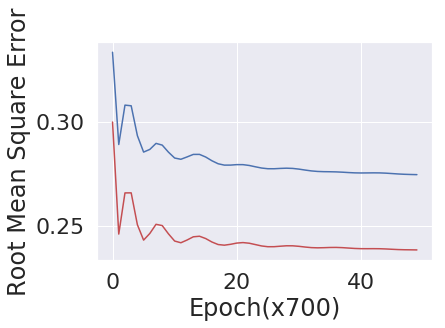

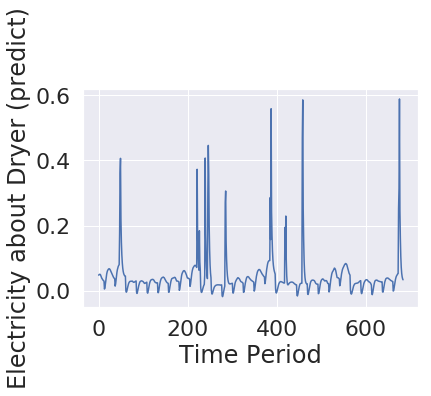

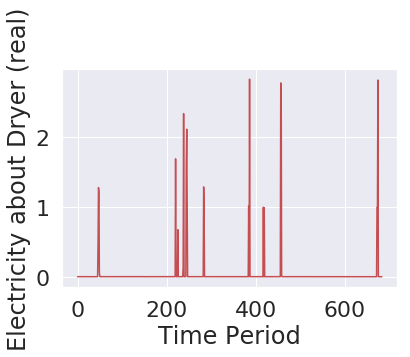

In [30]:
plt.figure(1)
plt.plot(train_error_summary, 'r')
plt.plot(test_error_summary, 'b')
plt.xlabel('Epoch(x700)')
plt.ylabel('Root Mean Square Error')

plt.figure(2)
plt.plot(test_predict, 'b')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (predict)')

plt.figure(3)
plt.plot(testY, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (real)')
plt.show()

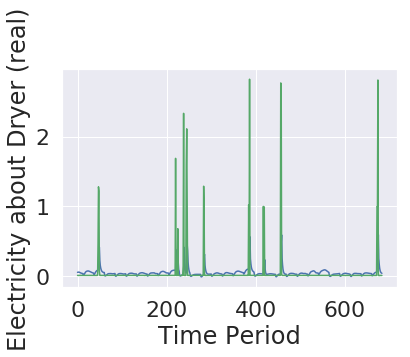

In [31]:
plt.figure()
plt.plot(predict_array[0],'b')
plt.plot(testY, 'g')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (real)')
plt.show()

In [32]:
time_electric_test = []
time_1 = 0
time_2 = 0
time_3 = 0
time_4 = 0
time_5 = 0
time_6 = 0
time_7 = 0
time_8 = 0
time_9 = 0
time_10 = 0
time_11 = 0
time_12 = 0
time_13 = 0
time_14 = 0
time_15 = 0
time_16 = 0
time_17 = 0
time_18 = 0
time_19 = 0
time_20 = 0
time_21 = 0
time_22 = 0
time_23 = 0
time_24 = 0
for i in range(len(testY)):
    if(i%24 == 0):
        time_1 += testY[i]
    elif(i%24 == 1):
        time_2 += testY[i]
    elif(i%24 == 2):
        time_3 += testY[i]
    elif(i%24 == 3):
        time_4 += testY[i]
    elif(i%24 == 4):
        time_5 += testY[i]
    elif(i%24 == 5):
        time_6 += testY[i]
    elif(i%24 == 6):
        time_7 += testY[i]
    elif(i%24 == 7):
        time_8 += testY[i]
    elif(i%24 == 8):
        time_9 += testY[i]
    elif(i%24 == 9):
        time_10 += testY[i]
    elif(i%24 == 10):
        time_11 += testY[i]
    elif(i%24 == 11):
        time_12 += testY[i]
    elif(i%24 == 12):
        time_13 += testY[i]
    elif(i%24 == 13):
        time_14 += testY[i]
    elif(i%24 == 14):
        time_15 += testY[i]
    elif(i%24 == 15):
        time_16 += testY[i]
    elif(i%24 == 16):
        time_17 += testY[i]
    elif(i%24 == 17):
        time_18 += testY[i]
    elif(i%24 == 18):
        time_19 += testY[i]
    elif(i%24 == 19):
        time_20 += testY[i]
    elif(i%24 == 20):
        time_21 += testY[i]
    elif(i%24 == 21):
        time_22 += testY[i]
    elif(i%24 == 22):
        time_23 += testY[i]
    elif(i%24 == 23):
        time_24 += testY[i]
        
time_electric_test = [time_1, time_2, time_3, time_4, time_5, time_6, time_7, time_8, time_9, time_10, time_11, time_12, time_13, time_14, time_15, time_16, time_17, time_18, time_19, time_20, time_21, time_22, time_23, time_24]

In [33]:
time_electric_predict = []

time_1 = 0
time_2 = 0
time_3 = 0
time_4 = 0
time_5 = 0
time_6 = 0
time_7 = 0
time_8 = 0
time_9 = 0
time_10 = 0
time_11 = 0
time_12 = 0
time_13 = 0
time_14 = 0
time_15 = 0
time_16 = 0
time_17 = 0
time_18 = 0
time_19 = 0
time_20 = 0
time_21 = 0
time_22 = 0
time_23 = 0
time_24 = 0

for i in range(len(predict_array[0])):
    
    if(i%24 == 0):
        time_1 += predict_array[0][i][0]
    elif(i%24 == 1):
        time_2 += predict_array[0][i][0]
    elif(i%24 == 2):
        time_3 += predict_array[0][i][0]
    elif(i%24 == 3):
        time_4 += predict_array[0][i][0]
    elif(i%24 == 4):
        time_5 += predict_array[0][i][0]
    elif(i%24 == 5):
        time_6 += predict_array[0][i][0]
    elif(i%24 == 6):
        time_7 += predict_array[0][i][0]
    elif(i%24 == 7):
        time_8 += predict_array[0][i][0]
    elif(i%24 == 8):
        time_9 += predict_array[0][i][0]
    elif(i%24 == 9):
        time_10 += predict_array[0][i][0]
    elif(i%24 == 10):
        time_11 += predict_array[0][i][0]
    elif(i%24 == 11):
        time_12 += predict_array[0][i][0]
    elif(i%24 == 12):
        time_13 += predict_array[0][i][0]
    elif(i%24 == 13):
        time_14 += predict_array[0][i][0]
    elif(i%24 == 14):
        time_15 += predict_array[0][i][0]
    elif(i%24 == 15):
        time_16 += predict_array[0][i][0]
    elif(i%24 == 16):
        time_17 += predict_array[0][i][0]
    elif(i%24 == 17):
        time_18 += predict_array[0][i][0]
    elif(i%24 == 18):
        time_19 += predict_array[0][i][0]
    elif(i%24 == 19):
        time_20 += predict_array[0][i][0]
    elif(i%24 == 20):
        time_21 += predict_array[0][i][0]
    elif(i%24 == 21):
        time_22 += predict_array[0][i][0]
    elif(i%24 == 22):
        time_23 += predict_array[0][i][0]
    elif(i%24 == 23):
        time_24 += predict_array[0][i][0]
        
time_electric_predict = [time_1, time_2, time_3, time_4, time_5, time_6, time_7, time_8, time_9, time_10, time_11, time_12, time_13, time_14, time_15, time_16, time_17, time_18, time_19, time_20, time_21, time_22, time_23, time_24]

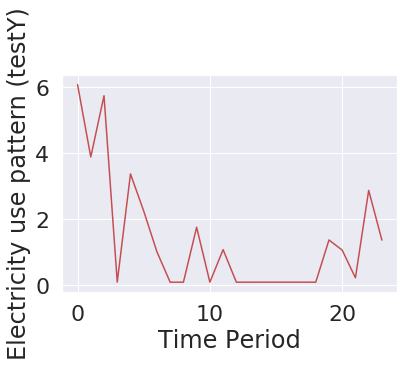

In [34]:
plt.figure()
plt.plot(time_electric_test, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity use pattern (testY)')
plt.show()

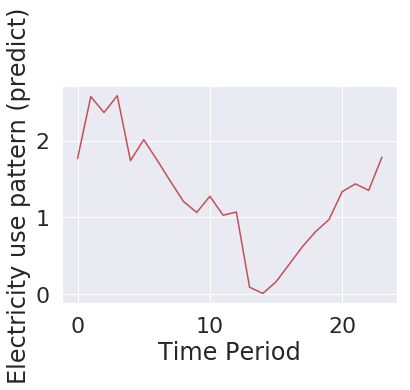

In [35]:
plt.figure()
plt.plot(time_electric_predict, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity use pattern (predict)')
plt.show()